# Importing Libraries

In [77]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


# Loading Excel file

In [79]:

df=pd.read_excel('Online Retail.xlsx')
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


# Removing Missing values

In [80]:

df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [81]:
df=df.dropna(subset=['CustomerID'])
df['Description']=df['Description'].isna().replace('Unknown')
df['CustomerID'] = df['CustomerID'].astype(int)

/tmp/ipython-input-3185406201.py:2: FutureWarning: Series.replace without 'value' and with non-dict-like 'to_replace' is deprecated and will raise in a future version. Explicitly specify the new values instead.
  df['Description']=df['Description'].isna().replace('Unknown')


# Explorator Data Analysis(EDA)

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  bool          
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  int64         
 7   Country      406829 non-null  object        
dtypes: bool(1), datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 25.2+ MB


In [83]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,406829.000000,406829,406829.000000,406829.000000
mean,12.061303,2011-07-10 16:30:57.879207424,3.460471,15287.690570
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,2.000000,2011-04-06 15:02:00,1.250000,13953.000000
50%,5.000000,2011-07-31 11:48:00,1.950000,15152.000000
75%,12.000000,2011-10-20 13:06:00,3.750000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,248.693370,NaN,69.315162,1713.600303


In [84]:
df['CustomerID'].nunique()

4372

## Feature Engeering (RFM) Tabel

In [85]:
df["Totalamount"]=df["UnitPrice"]*df["Quantity"]
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"])
refencedays=df['InvoiceDate'].max()+pd.Timedelta(days=1)
rfm=df.groupby('CustomerID').agg({
    'InvoiceDate':lambda x:(refencedays-x.max()).days,
    'InvoiceNo':"nunique",
    "Totalamount":"sum"

}).reset_index()
rfm.columns=["CustomerID","Recency","Frequency","Monetary"]
rfm.head()


,CustomerID,Recency,Frequency,Monetary
0,12346,326,2,0.00
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


## Scaling Data Using Standard-SCALER

In [86]:
scale=StandardScaler()
rfm_scaled=scale.fit_transform(rfm[["Recency","Frequency","Monetary"]])
rfm_scaled.shape

(4372, 3)

## Customer Segmentation using k-means using Elbow method


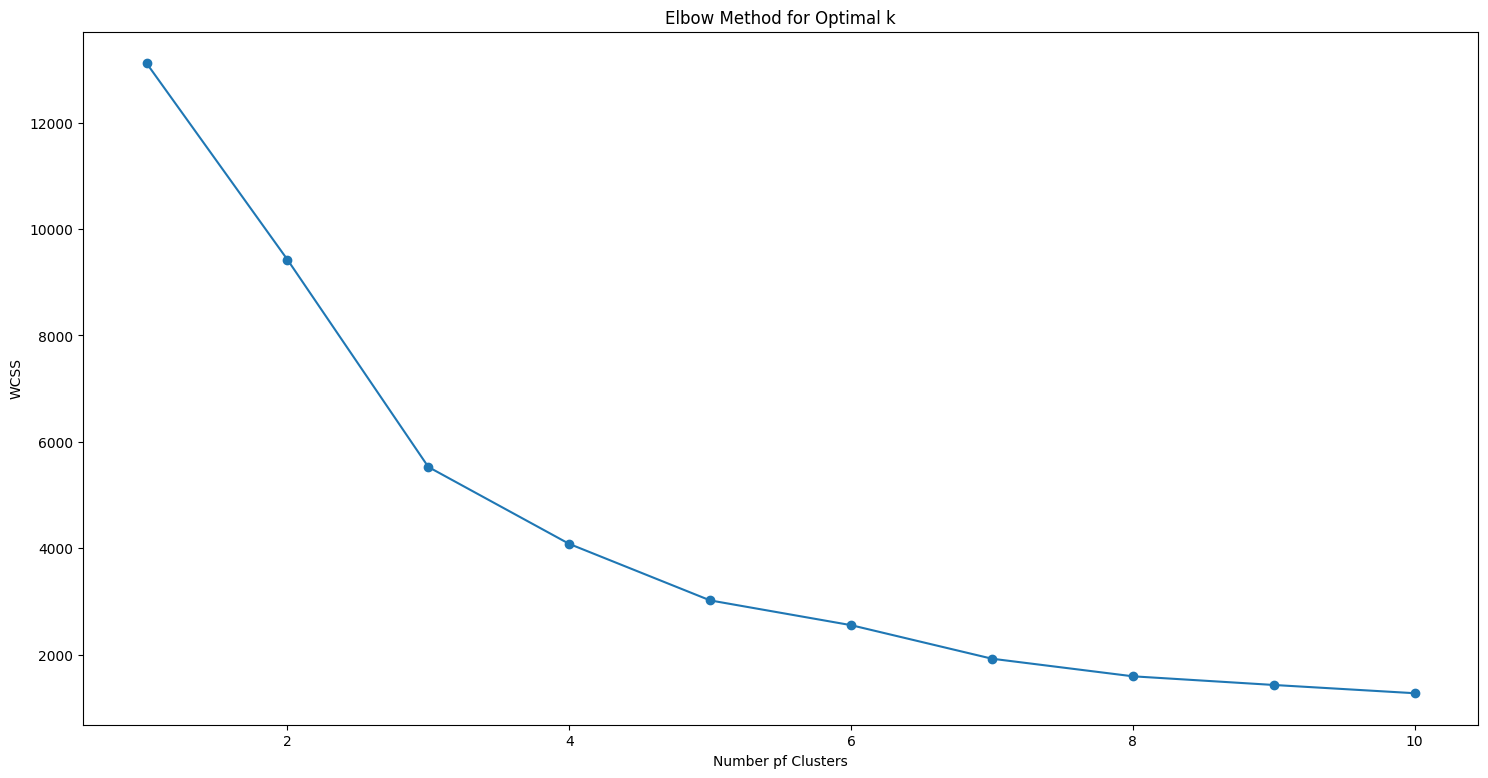

In [87]:
wcss=[]
for i in range(1,11):
  k_means=KMeans(n_clusters=i,random_state=42)
  k_means.fit(rfm_scaled)
  wcss.append(k_means.inertia_)
plt.figure(figsize=(18,9))
plt.plot(range(1,11),wcss,marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel("Number pf Clusters")
plt.ylabel("WCSS")
plt.show()


## Applying K-means

In [88]:
k_means=KMeans(n_clusters=6,random_state=42)
k_means.fit(rfm_scaled)
rfm["Clusters"]=k_means.labels_
print(rfm["Clusters"].value_counts())

Clusters
0    2631
3     791
1     626
5     301
2      20
4       3
Name: count, dtype: int64


## Visualizating and Getting Insights



## 1-Histplot Visualization

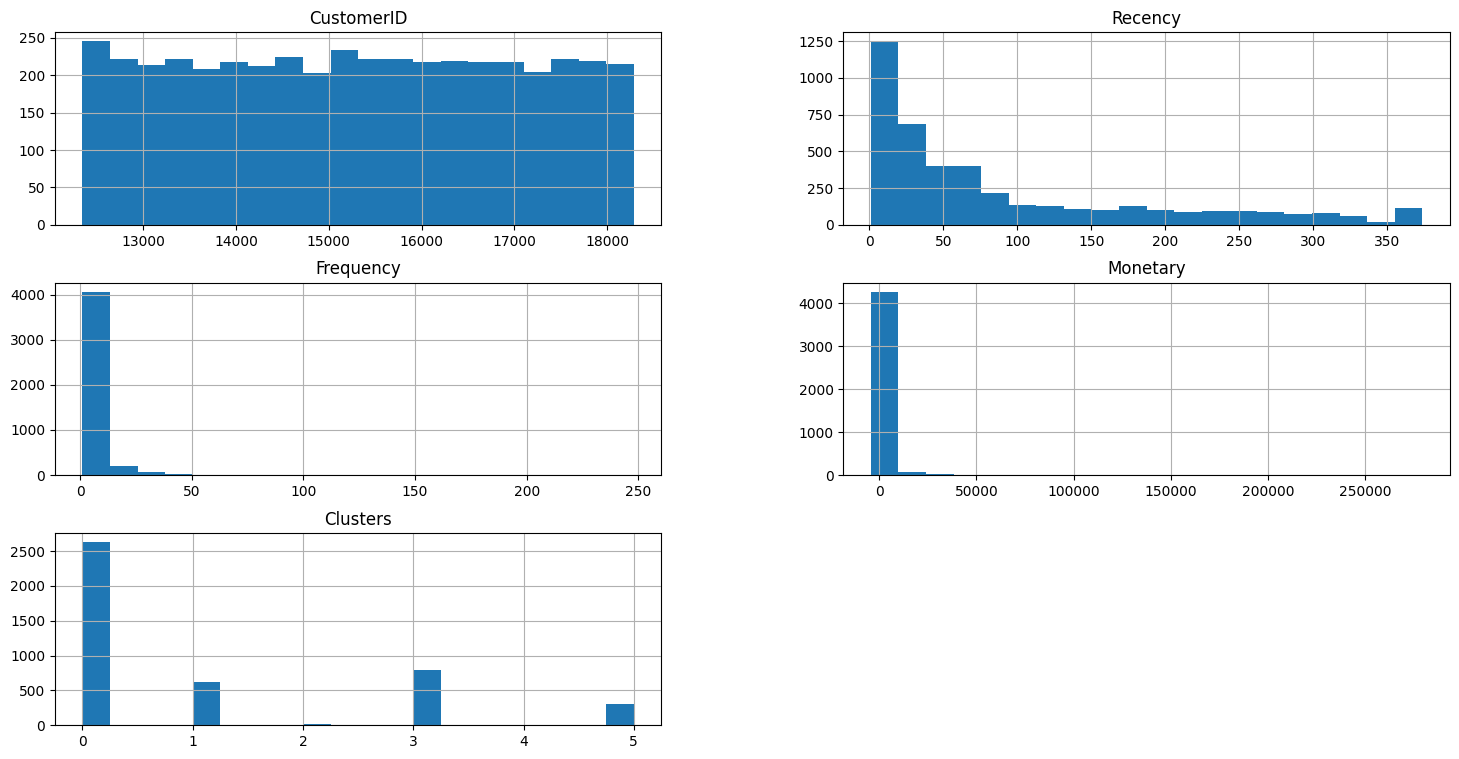

In [89]:
rfm.hist(figsize=(18,9),bins=20)
plt.show()

## 2- PariPlot Visualization




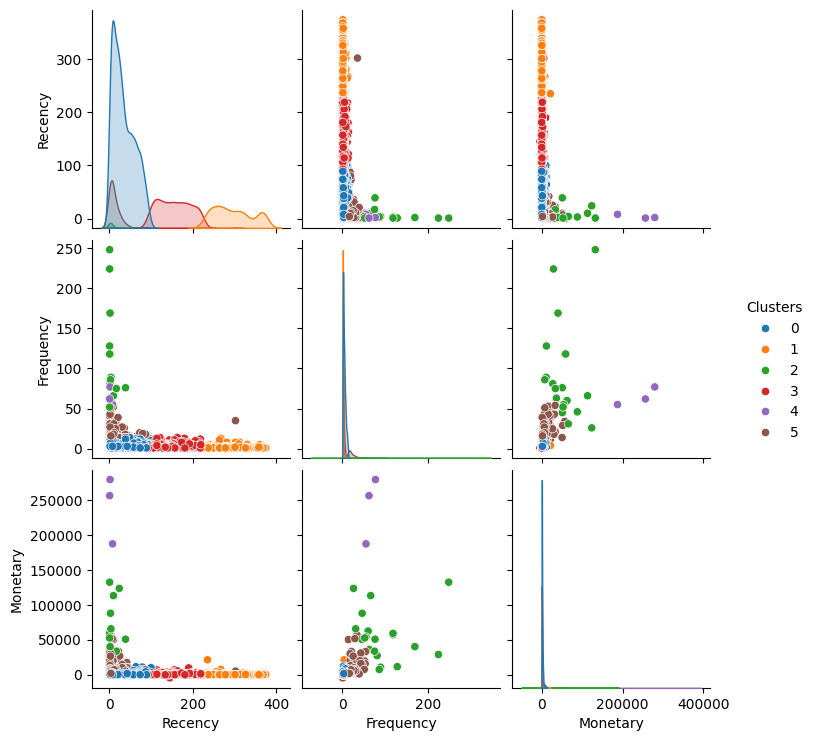

In [90]:
sns.pairplot(rfm,hue="Clusters",vars=["Recency","Frequency","Monetary"],palette='tab10')
plt.show()

## 3- Scatter plot Visualization

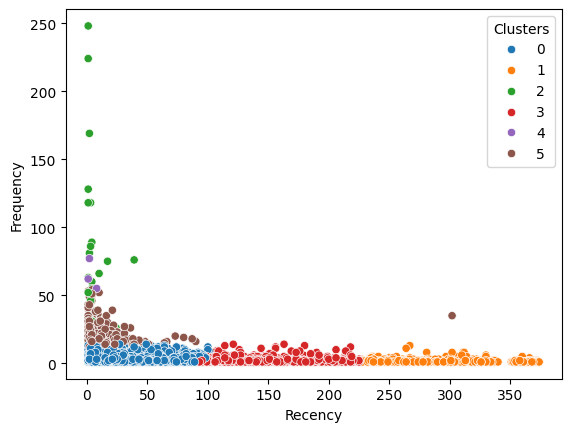

In [91]:
sns.scatterplot(data=rfm,x="Recency",y="Frequency",hue="Clusters",palette='tab10')
plt.show()

## Using Principle Component Analysis

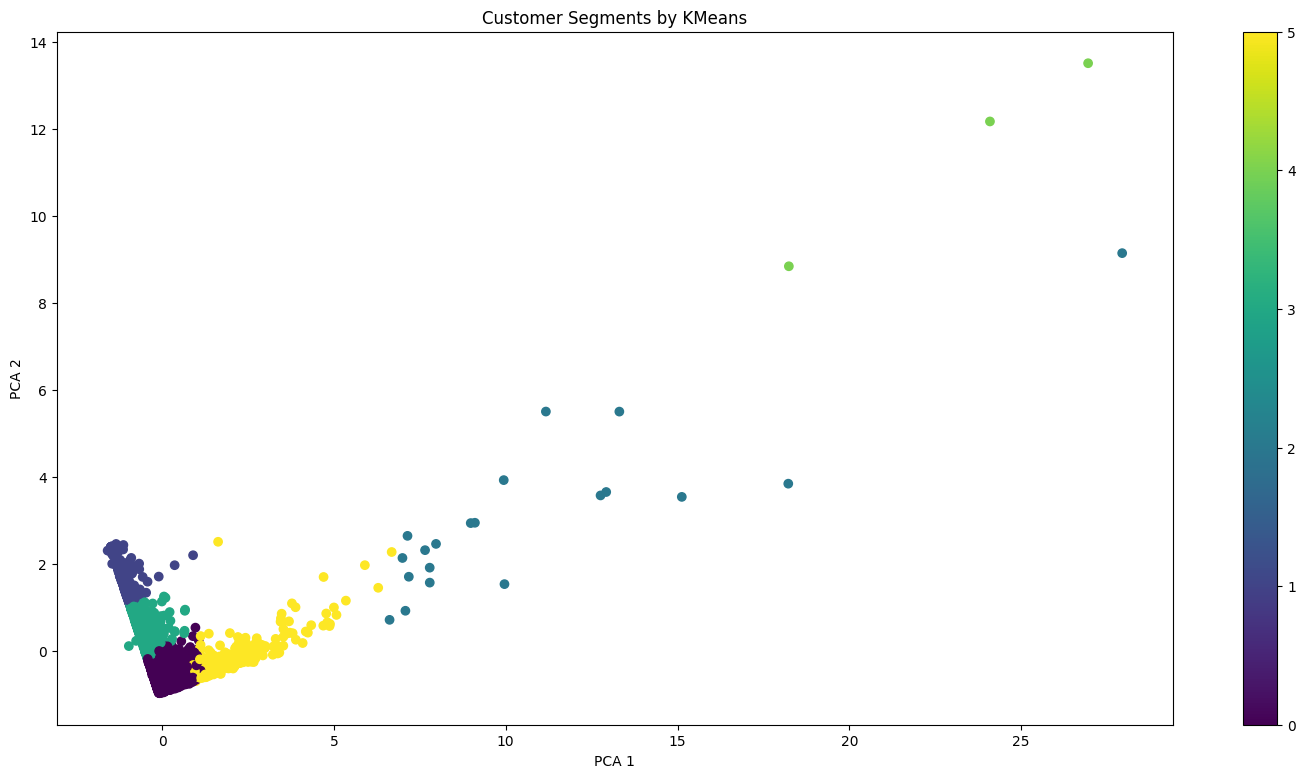

In [92]:

pca=PCA(n_components=2)
components=pca.fit_transform(rfm_scaled)
plt.figure(figsize=(18,9))
plt.scatter(components[:,0],components[:,1],c=rfm['Clusters'],cmap='viridis')
plt.title('Customer Segments by KMeans')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar()
plt.show()

##Data Profiling

In [93]:
print(rfm.groupby('Clusters').mean())

            CustomerID     Recency  Frequency       Monetary
Clusters                                                    
0         15303.139111   34.196503   4.103003    1249.436668
1         15290.600639  296.146965   1.503195     398.270160
2         14871.450000    6.400000  92.800000   55470.275500
3         15351.651075  155.509482   2.458913     660.920418
4         16732.666667    3.666667  64.666667  241136.560000
5         15165.890365   13.036545  21.458472    7999.593289
